In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.transform import transform

## Cargamos los datos correctamente para analizarlos

In [9]:
df = transform()
df

,planet_name,star_name,num_stars,num_planets,num_moons,discovery_method,discovery_year,discovery_locale,discovery_facility,discovery_telescope,...,ra_deg,dec_deg,hz_inner,hz_outer,eff_distance,habitability,temp_habitability,planet_type,spectral_type,discovery_era
0,HD 80653 b,HD 80653,1,2,0,Transit,2020,Space,K2,0.95 m Kepler Telescope,...,140.339085,14.367869,0.956943,2.258386,0.016570,Muy cerca,hT - hyperthermoplanet,Super-Earth,G,Era TESS
1,K2-312 c,HD 80653,1,2,0,Radial Velocity,2023,Ground,Roque de los Muchachos Observatory,3.58 m Telescopio Nazionale Galileo,...,140.339085,14.367869,0.956943,2.258386,2.551514,Muy lejos,P - psychroplanet,Jovian-like,G,Era TESS
2,XO-2 S d,XO-2 S,2,4,0,Radial Velocity,2024,Ground,Multiple Observatories,Multiple Telescopes,...,117.030975,50.216907,0.650955,1.536255,5.482607,Muy lejos,hP - hypopsychroplanet,Jovian-like,G,Era TESS
3,Kepler-1808 b,Kepler-1808,1,1,0,Transit,2021,Space,Kepler,0.95 m Kepler Telescope,...,287.292474,39.383204,0.697993,1.647264,0.146700,Muy cerca,hT - hyperthermoplanet,Sub-Neptune,G,Era TESS
4,Kepler-418 b,Kepler-418,1,2,0,Transit,2014,Space,Kepler,0.95 m Kepler Telescope,...,294.433523,38.355473,0.852376,2.011608,0.400340,Muy cerca,hT - hyperthermoplanet,Jovian-like,G,Era Kepler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6331,TOI-2384 b,TOI-2384,2,1,0,Transit,2024,Space,Transiting Exoplanet Survey Satellite (TESS),0.1 m TESS Telescope,...,36.156146,-65.000196,0.206788,0.488021,0.027930,Muy cerca,hT - hyperthermoplanet,Jovian-like,K,Era TESS
6332,TOI-5292 A b,TOI-5292 A,2,1,0,Transit,2026,Space,Transiting Exoplanet Survey Satellite (TESS),0.1 m TESS Telescope,...,344.222363,-8.119747,0.211070,0.498125,0.027916,Muy cerca,hT - hyperthermoplanet,Jovian-like,K,Era TESS
6333,TIC 46432937 b,TIC 46432937,2,1,0,Transit,2024,Space,Transiting Exoplanet Survey Satellite (TESS),0.1 m TESS Telescope,...,83.868979,-14.597191,0.152234,0.359272,0.020651,Muy cerca,hT - hyperthermoplanet,Jovian-like,M,Era TESS
6334,HD 60779 b,HD 60779,1,2,0,Transit,2026,Space,Transiting Exoplanet Survey Satellite (TESS),0.1 m TESS Telescope,...,114.004758,-3.151291,0.938548,2.214972,0.192292,Muy cerca,hT - hyperthermoplanet,Sub-Neptune,F,Era TESS


## Contamos los valores nulos

In [10]:
df.isnull().sum()

planet_name                0
star_name                  0
num_stars                  0
num_planets                0
num_moons                  0
discovery_method           0
discovery_year             0
discovery_locale           0
discovery_facility         0
discovery_telescope        0
discovery_instrument       0
orbital_period_days      344
semi_major_axis_au       428
eccentricity            1053
planet_radius_earth       50
equilibrium_temp_k       526
star_temp_k              297
star_radius_solar        321
star_mass_solar            9
star_luminosity_log      315
distance_pc               27
ra_deg                     0
dec_deg                    0
hz_inner                 315
hz_outer                 315
eff_distance            1123
habitability               0
temp_habitability          0
planet_type                0
spectral_type              0
discovery_era              0
dtype: int64

La mayor cantidad de nulos se encuentra en **eff_distance**, gran parte debido a que para su cálculo se usa **eccentricity** que tiene casi 1000 nulos, luego **equilibrium_temp_k** con 526 nulos, pero las otras columnas tienen una cantidad de nulos menor al 5%, lo que es aceptable para nuestro propósito de mostrar data.

In [11]:
df.describe()

,num_stars,num_planets,num_moons,discovery_year,orbital_period_days,semi_major_axis_au,eccentricity,planet_radius_earth,equilibrium_temp_k,star_temp_k,star_radius_solar,star_mass_solar,star_luminosity_log,distance_pc,ra_deg,dec_deg,hz_inner,hz_outer,eff_distance
count,6336.000000,6336.000000,6336.0,6336.0,5.992000e+03,5908.000000,5283.000000,6286.000000,5810.000000,6039.000000,6015.000000,6327.000000,6021.000000,6309.000000,6336.000000,6336.000000,6021.000000,6021.000000,5213.000000
mean,1.101641,1.759785,0.0,2017.249369,7.144464e+04,15.545361,0.079915,5.851832,834.896141,5394.344078,1.489258,0.934775,-0.145965,704.333640,230.713841,17.549925,0.969003,2.286848,1.073830
std,0.339586,1.150985,0.0,5.119349,5.195691e+06,346.853588,0.153173,5.422517,496.619821,1727.761286,3.864738,0.387024,0.780740,1215.826842,92.611489,37.658890,1.768123,4.172771,12.420869
min,1.000000,1.000000,0.0,1992.0,9.070629e-02,0.004400,0.000000,0.309800,1.480000,415.000000,0.011500,0.009400,-6.090000,1.301190,0.185606,-89.471513,0.000676,0.001596,0.004408
25%,1.000000,1.000000,0.0,2014.0,4.308908e+00,0.052300,0.000000,1.850000,485.895000,4898.500000,0.770000,0.770000,-0.473960,101.251000,168.226736,-12.525095,0.434592,1.025636,0.052000
50%,1.000000,1.000000,0.0,2016.0,1.074551e+01,0.102750,0.000000,2.860000,755.625000,5544.000000,0.950000,0.940000,-0.079170,360.313000,284.335606,38.947263,0.684662,1.615802,0.099150
75%,1.000000,2.000000,0.0,2021.0,3.856275e+01,0.311250,0.092000,11.915990,1092.750000,5899.500000,1.249295,1.087500,0.310000,823.242000,293.086590,45.417147,1.071670,2.529142,0.249900
max,4.000000,8.000000,0.0,2026.0,4.020000e+08,19000.000000,0.950000,87.205870,7777.780000,57000.000000,88.475000,9.100000,3.800000,8500.000000,359.974984,88.829876,59.574618,140.596098,600.480000


 ## Distribución segun distancia desde la tierra

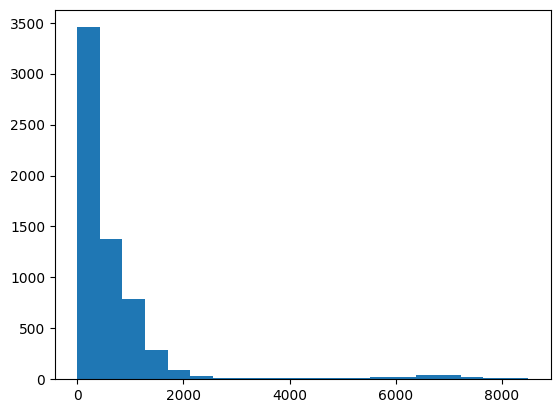

In [12]:
plt.hist(df['distance_pc'].dropna(), bins = 20)
plt.show()

Vemos que la mayoría de planetas encontrados se encuentran cerca de la tierra, eso seguramente por que los planetas más cercanos son más fáciles de encontrar.

## Distribución según año de descubrimiento

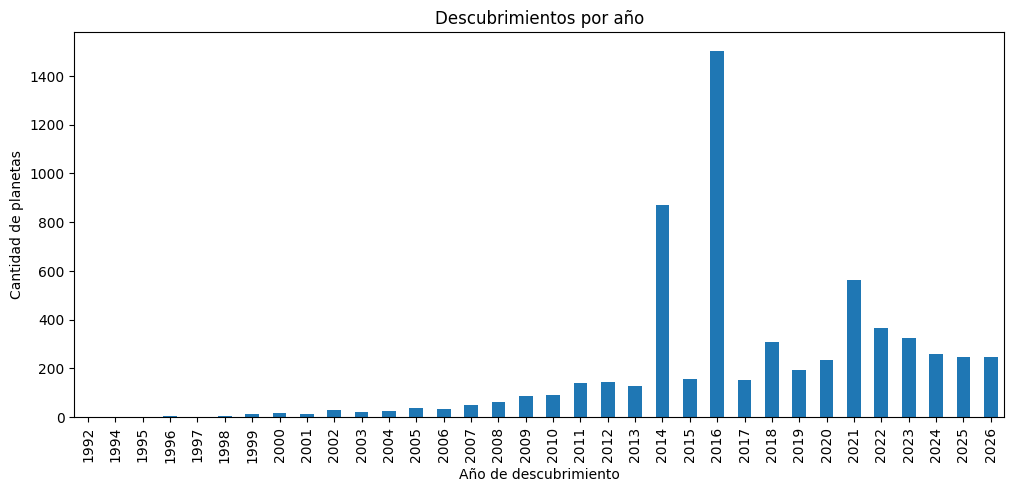

In [13]:
conteo_por_año = df['discovery_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
conteo_por_año.plot(kind='bar')
plt.xlabel('Año de descubrimiento')
plt.ylabel('Cantidad de planetas')
plt.title('Descubrimientos por año')
plt.show()

La mayor cantidad de descubrimientos se dió entre 2014 y 2016, aunque teniendo en cuenta que el año que se pone no es cuando se visualiza por primera vez un planeta, sino cuando se confirma que lo es, entonces podría ser gracias a que la mayor confirmación de planetas se dió en esta época, que cumple con ser la era Kepler.

## Distribución según método

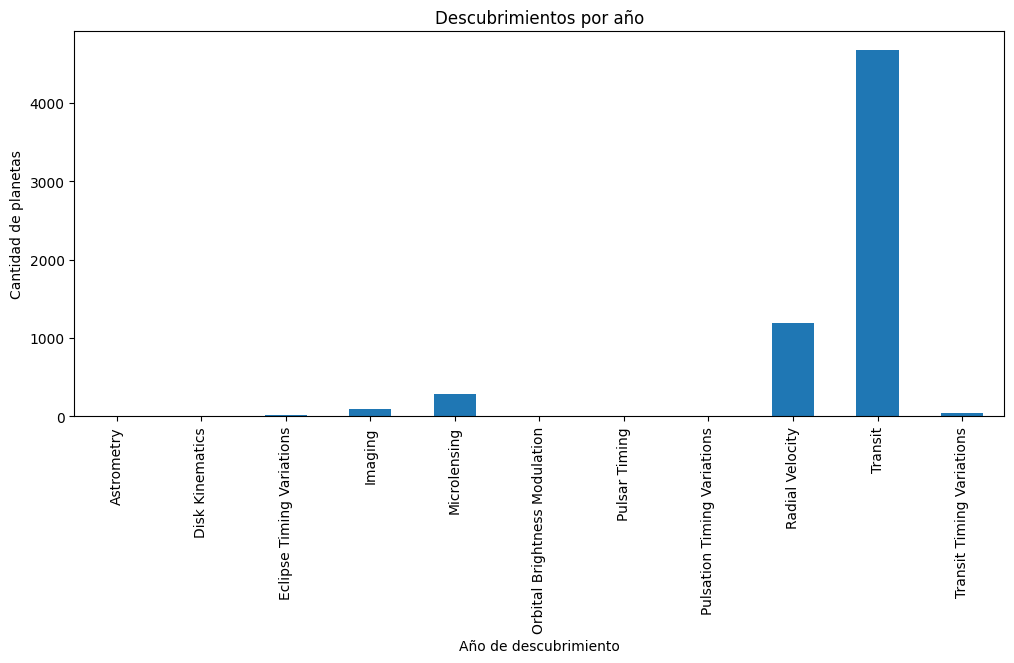

In [14]:
conteo_por_año = df['discovery_method'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
conteo_por_año.plot(kind='bar')
plt.xlabel('Año de descubrimiento')
plt.ylabel('Cantidad de planetas')
plt.title('Descubrimientos por año')
plt.show()

Está claro que el método transitorio es el que más descubrimientos tiene, seguidi por velocidad radial.

## Distribución por habitabilidad

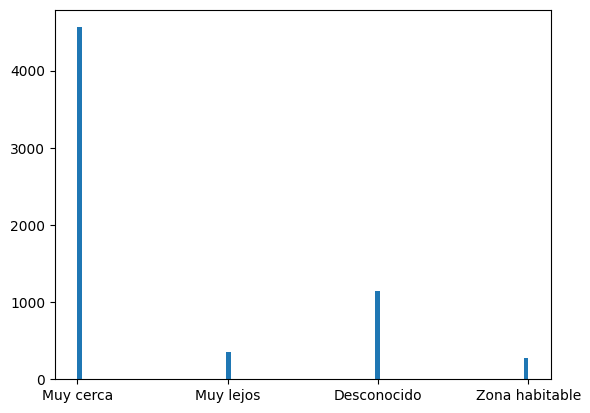

In [15]:
plt.hist(df['habitability'].dropna(), bins = 100)
plt.show()

Vemos que la mayoría de planetas descubiertos estan cerca de su estrella, eso esta conectado con la distribución anterior, los planetas mas cercanos son más fáciles de encontrar por el método transitorio.

In [16]:
df['distance_pc'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
df['distance_pc'].describe()

count    6309.000000
mean      704.333640
std      1215.826842
min         1.301190
25%       101.251000
50%       360.313000
75%       823.242000
max      8500.000000
Name: distance_pc, dtype: float64

In [17]:
import seaborn as sns

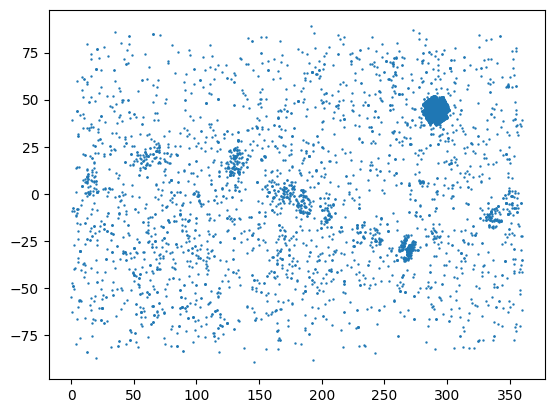

In [33]:
x = df["ra_deg"]
y = df["dec_deg"]

plt.scatter(x,y, s = 0.5)
plt.show()

# sns.scatterplot(df, x = "ra_deg", y = "dec_deg", size = 0.01)

In [19]:
ra_rad = np.radians(df['ra_deg'])
dec_rad = np.radians(df['dec_deg'])
r = df['distance_pc']

df['x'] = r * np.cos(dec_rad) * np.cos(ra_rad)
df['y'] = r * np.cos(dec_rad) * np.sin(ra_rad)
df['z'] = r * np.sin(dec_rad)

In [ ]:
pip install plotly